In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif

In [6]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [8]:
print("Shape:", df.shape)
print("Number of columns:", len(df.columns))
print("Last column:", df.columns[-1])
df.head()

Shape: (2827876, 79)
Number of columns: 79
Last column: Label


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [9]:
print("Label distribution:")
print(df["Label"].value_counts())

print("\nLabel percentages:")
print((df["Label"].value_counts(normalize=True) * 100).round(2))

Label distribution:
0    2271320
1     556556
Name: Label, dtype: int64

Label percentages:
0    80.32
1    19.68
Name: Label, dtype: float64


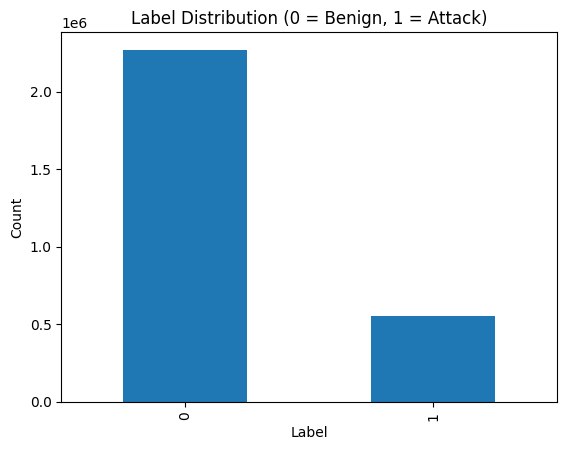

In [10]:
df["Label"].value_counts().plot(kind="bar")
plt.title("Label Distribution (0 = Benign, 1 = Attack)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [11]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 0


In [12]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
count,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,...,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06
mean,8.061534e+03,1.480065e+07,9.368972e+00,1.040396e+01,5.498522e+02,1.617903e+04,2.078044e+02,1.872929e+01,5.825628e+01,6.897811e+01,...,-2.744494e+03,8.163400e+04,4.117582e+04,1.533378e+05,5.835492e+04,8.324468e+06,5.043548e+05,8.704568e+06,7.928061e+06,1.968106e-01
std,1.827432e+04,3.366750e+07,7.500527e+02,9.978937e+02,9.998639e+03,2.264235e+06,7.175183e+02,6.035533e+01,1.861733e+02,2.813212e+02,...,1.085539e+06,6.489234e+05,3.935787e+05,1.026333e+06,5.773818e+05,2.364057e+07,4.605289e+06,2.437766e+07,2.337390e+07,3.975880e-01
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,2.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.133800e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.239368e+06,5.000000e+00,4.000000e+00,1.880000e+02,4.840000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08,1.000000e+00


In [13]:
X = df.drop("Label", axis=1)
y = df["Label"]

constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
print("Constant columns removed:", constant_cols)

X = X.drop(columns=constant_cols)
print("Shape after removing constant columns:", X.shape)

Constant columns removed: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Shape after removing constant columns: (2827876, 70)


In [14]:
selector = SelectKBest(score_func=f_classif, k=15)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected features:")
print(selected_features)

Selected features:
Index(['Bwd Packet Length Max', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Std', 'Fwd IAT Max',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'Average Packet Size', 'Avg Bwd Segment Size',
       'Idle Mean', 'Idle Max', 'Idle Min'],
      dtype='object')


In [15]:
df_selected = df[selected_features.tolist() + ["Label"]]
df_selected.to_csv("../data/curated/selected_features.csv", index=False)

print("Curated dataset saved successfully")
print("Curated shape:", df_selected.shape)

Curated dataset saved successfully
Curated shape: (2827876, 16)


In [16]:
df_selected.head()

,Bwd Packet Length Max,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Max,Fwd IAT Std,Fwd IAT Max,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,Average Packet Size,Avg Bwd Segment Size,Idle Mean,Idle Max,Idle Min,Label
0,0,0.0,0.0,3,0.0,3,6,6.0,0.0,0.0,9.0,0.0,0.0,0,0,0
1,6,6.0,0.0,109,0.0,0,6,6.0,0.0,0.0,9.0,6.0,0.0,0,0,0
2,6,6.0,0.0,52,0.0,0,6,6.0,0.0,0.0,9.0,6.0,0.0,0,0,0
3,6,6.0,0.0,34,0.0,0,6,6.0,0.0,0.0,9.0,6.0,0.0,0,0,0
4,0,0.0,0.0,3,0.0,3,6,6.0,0.0,0.0,9.0,0.0,0.0,0,0,0


In [17]:
print("Selected feature dataset columns:")
print(df_selected.columns.tolist())

Selected feature dataset columns:
['Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Std', 'Fwd IAT Max', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Avg Bwd Segment Size', 'Idle Mean', 'Idle Max', 'Idle Min', 'Label']
